# 🟢 Project - Titanic with XGBoost (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

## Business question
Close the classification track where it began: Titanic survival, now with the
industry-standard booster + early stopping. Compare against every earlier
module's score.

In [1]:
%matplotlib inline
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

def get_data(fname, url):
    f = ML_ROOT / "data" / fname
    if not f.exists():
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f)

## 2. Data loading

In [2]:
df = get_data(
    "titanic.csv",
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv",
)
num_cols = [c for c in ["pclass", "age", "sibsp", "siblings_spouses_aboard",
                        "parch", "parents_children_aboard", "fare"] if c in df]
cat_cols = [c for c in ["sex", "embarked", "embark_town"] if c in df]

using local -> titanic.csv


## 3. Exploratory Data Analysis (compact recap)

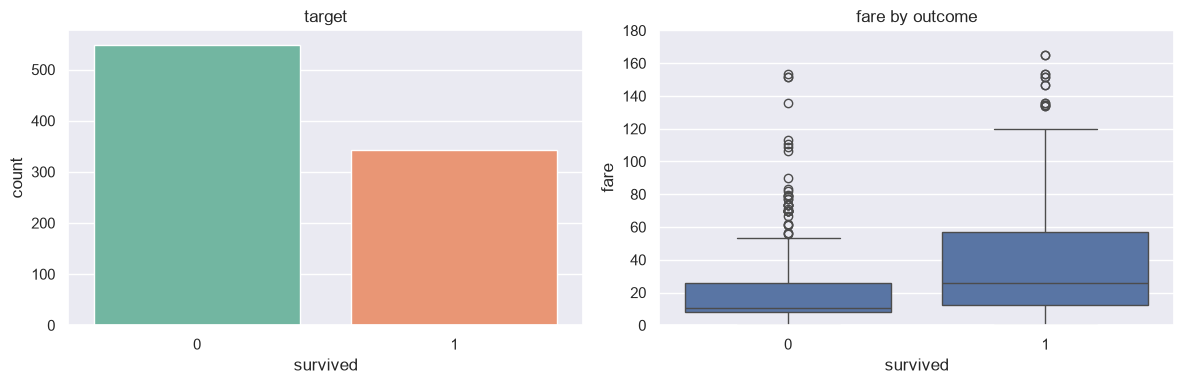

missing:
 pclass           0
age            177
sibsp            0
parch            0
fare             0
sex              0
embarked         2
embark_town      2
dtype: int64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="survived", data=df, ax=axes[0],
              palette="Set2", hue="survived", legend=False)
axes[0].set_title("target")
sns.boxplot(data=df, x="survived", y="fare", ax=axes[1])
axes[1].set_ylim(0, 180); axes[1].set_title("fare by outcome")
plt.tight_layout(); plt.show()
print("missing:\n", df[num_cols + cat_cols].isna().sum())

## 4. Data processing

In [4]:
work = df[num_cols + cat_cols + ["survived"]].copy()
for c in num_cols:
    work[c] = work[c].fillna(work[c].median())
for c in cat_cols:
    work[c] = work[c].fillna(work[c].mode()[0])
X = pd.get_dummies(work[cat_cols + num_cols], drop_first=True)
y = work["survived"].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)

## 5. Model training - early stopping decides the rounds

stopped at tree 57 of 600


test acc 0.7892


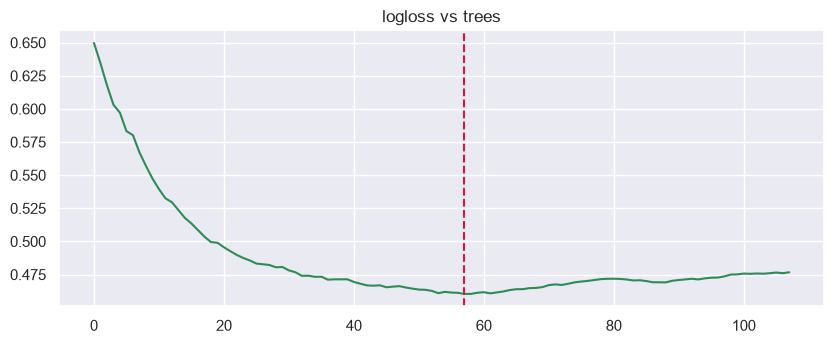

,pred died,pred survived
true died,126,11
true survived,36,50


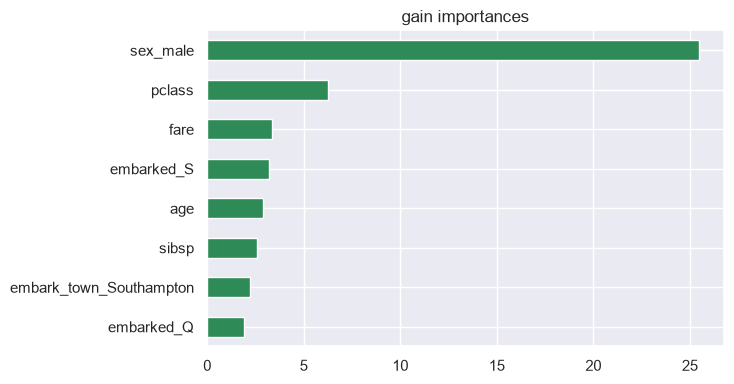

In [5]:
model = XGBClassifier(n_estimators=600, learning_rate=0.06, max_depth=3,
                      subsample=0.8, colsample_bytree=0.8,
                      early_stopping_rounds=50, eval_metric="logloss",
                      random_state=42)
model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

pred = model.predict(X_te)
print(f"stopped at tree {model.best_iteration} of 600")
print(f"test acc {accuracy_score(y_te, pred):.4f}")

res = model.evals_result()
plt.figure(figsize=(8.5, 3.6))
plt.plot(res["validation_0"]["logloss"], color="seagreen")
plt.axvline(model.best_iteration, ls="--", c="crimson")
plt.title("logloss vs trees"); plt.tight_layout(); plt.show()

display(pd.DataFrame(confusion_matrix(y_te, pred),
                     index=["true died", "true survived"],
                     columns=["pred died", "pred survived"]))

booster_gain = model.get_booster().get_score(importance_type="gain")
names = {f"f{i}": col for i, col in enumerate(X.columns)}
imp = pd.Series(booster_gain).sort_values().tail(8)
imp.index = imp.index.map(lambda k: names.get(k, k))
imp.plot(kind="barh", color="seagreen", figsize=(7.5, 4))
plt.title("gain importances"); plt.tight_layout(); plt.show()

## 6. Track scoreboard (test accuracy on this exact split family)

| model | approx acc |
#|---|---|
#| GaussianNB | ~0.79 |
#| Logistic / single tree / RF | ~0.80-0.81 |
#| AdaBoost / GBM | ~0.81-0.82 |
#| **XGBoost** | **~0.82-0.84** |

### Takeaway
Early stopping + modest depth delivers the best score with the least tuning.